# **NETFLIX** Business Case Study
- Netflix is one of the most popular media and video streaming platforms. They have over 10000 movies or tv shows available on their platform, as of mid-2021, they have over 222M Subscribers globally. This tabular dataset consists of listings of all the movies and tv shows available on Netflix, along with details such as - cast, directors, ratings, release year, duration, etc.

In [1]:
# Importing the required Python Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load the Netflix Dataset to be analysed

In [4]:
!gdown 1XWeptwqELLr0_7eZt4oLqhzHMb7TfmBp -O netflix.csv

Downloading...
From: https://drive.google.com/uc?id=1XWeptwqELLr0_7eZt4oLqhzHMb7TfmBp
To: /content/netflix.csv
100% 3.40M/3.40M [00:00<00:00, 148MB/s]


In [5]:
# Display first few rows of the datset

In [281]:
netflix = pd.read_csv('netflix.csv')
netflix.head(2)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."


# Understanding the Dataset: structure, shape, data types, information, columns

In [7]:
netflix.dtypes

,0
show_id,object
type,object
title,object
director,object
cast,object
country,object
date_added,object
release_year,int64
rating,object
duration,object


In [8]:
netflix.shape

(8807, 12)

In [9]:
netflix.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [10]:
# There are 6 columns, which are compltely NOn Null and other 6 have some cells which are Null/Na.

In [11]:
netflix.describe(include='all')

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8807.000000,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,NaN,17,220,514,8775
top,s8807,Movie,Zubaan,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.180198,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.819312,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


In [12]:
# From the above analysis it is evident the Netflix Platform currently has movies and tv shows which released in years ranging from 1925 to 2021.

In [13]:
netflix.nunique()

,0
show_id,8807
type,2
title,8807
director,4528
cast,7692
country,748
date_added,1767
release_year,74
rating,17
duration,220


In [14]:
# from the above information, we can deduce Netflix platorm currently provides content which were released in 74 different years
# There are total 8807 no. of movies/tv shows available to watch on Netflix as of now

In [15]:
netflix.duplicated().sum()

np.int64(0)

In [16]:
# It is confirmed that in dataset, there are no duplicate entries or rows.

# **Problem Statement**
- Analyze the data and generate insights that could help Netflix in deciding which type of shows/movies to produce and how they can grow the business in different countries

> Some Exploratory Problems:
1. What type of content is available in different countries?
1.	How has the number of movies released per year changed over the last 20-30 years?
2.	Comparison of tv shows vs. movies.
3.	What is the best time to launch a TV show?
4.	Analysis of actors/directors of different types of shows/movies.
5.	Does Netflix has more focus on TV Shows than movies in recent years
6.	Understanding what content is available in different countries




# Handling the missing Values

In [18]:
netflix.isna().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [19]:
# Handle the 'date_added' column for it null values, and convert the potential date columns into date_time

In [20]:
netflix['date_added'] = pd.to_datetime(netflix['date_added'], errors='coerce')


In [21]:
netflix['date_added'].isnull().sum()

np.int64(98)

In [22]:
# All the null values in 'date_added' column have been dealt with and has been replaced with Nat, i.e Not a Time.

In [23]:
# Now, for all other columns which have null entries and string types, replacing them with 'Unknown'

In [24]:
null_col = ['director', 'cast', 'country', 'rating', 'duration']
for col in null_col:
  netflix[col].fillna('Unknown', inplace=True)

/tmp/ipykernel_1554/2874067278.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  netflix[col].fillna('Unknown', inplace=True)


In [25]:
netflix.isna().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,98
release_year,0
rating,0
duration,0


In [26]:
# All null values have been dealt with, accordingly.

Conversion of Categorical Columns

In [27]:
cat_cols = ['type', 'director', 'cast', 'country', 'rating', 'listed_in' ]
for col in cat_cols:
  netflix[col] = netflix[col].astype('category')

Extraction of month and year of date_added

In [28]:
netflix['month_added'] = netflix['date_added'].dt.month_name()
netflix['year_added'] = netflix['date_added'].dt.year

# **Data Analysis**

In [29]:
# Movies v/s TV Shows

In [30]:
netflix['type'].value_counts()

,count
type,
Movie,6131
TV Show,2676


In [31]:
# Netflix is dominated by Movie Contents, alsmot 2.5 times more no. of movies available than that of TV Shows.

In [32]:
# Dfiffrent Ratings and their counts

netflix['rating'].value_counts()

,count
rating,
TV-MA,3207
TV-14,2160
TV-PG,863
R,799
PG-13,490
TV-Y7,334
TV-Y,307
PG,287
TV-G,220


In [33]:
# Different Years of content available on Netflix based on their release Year, sorted by Year latest first

netflix['release_year'].value_counts().sort_index(ascending = False)

,count
release_year,
2021,592
2020,953
2019,1030
2018,1147
2017,1032
...,...
1945,4
1944,3
1943,3


In [34]:
# Analysis of Countries in which the content was produced, Unique Countries

netflix['country'].nunique()

749

In [36]:
# Top Countries Producing contents

netflix['country'].value_counts().head(10)

,count
country,
United States,2818
India,972
Unknown,831
United Kingdom,419
Japan,245
South Korea,199
Canada,181
Spain,145
France,124


In [37]:
# US, India. Japan and UK dominate in producing the content. There are multiple contents which are produced in more than 1 country.

In [38]:
# Top Genres of content available

netflix['listed_in'].value_counts().head(10)

,count
listed_in,
"Dramas, International Movies",362
Documentaries,359
Stand-Up Comedy,334
"Comedies, Dramas, International Movies",274
"Dramas, Independent Movies, International Movies",252
Kids' TV,220
Children & Family Movies,215
"Children & Family Movies, Comedies",201
"Documentaries, International Movies",186


In [39]:
# Dramas, International Movies, Documentaries, Stand-Up Comedy, dominate the collections.

# Categorical Non - Graphical analysis

Data Processing is required for following columns:

* cast
* director
* country
* listed_in

They conatin multiple categories within themselves in each entry.


Data Pre Processing

In [40]:
# Individual Countrys for a movie/tv show
country_n = netflix.assign(country = netflix['country'].str.split(',')).explode('country')
country_n['country'] = country_n['country'].str.strip()

# Individual Cast for a movie/tv show
cast_n = netflix.assign(cast = netflix['cast'].str.split(',')).explode('cast')
cast_n['cast'] = cast_n['cast'].str.strip()

# Individual Director for a movie/tv show
director_n = netflix.assign(director = netflix['director'].str.split(',')).explode('director')
director_n['director'] = director_n['director'].str.strip()

# Individual listed_in genres for a movie/tv show
listed_in_n = netflix.assign(listed_in = netflix['listed_in'].str.split(',')).explode('listed_in')
listed_in_n['listed_in'] = listed_in_n['listed_in'].str.strip()

In [41]:
# No. of different Countries content on Netflix

country_n['country'].nunique()

124

In [42]:
# Top Countries prducing content, available on Netflix

country_n['country'].value_counts().head(10)

,count
country,
United States,3690
India,1046
Unknown,831
United Kingdom,806
Canada,445
France,393
Japan,318
Spain,232
South Korea,231


In [43]:
# Netflix hosts content originating from 124 unique countries, indicating a highly diverse global content library.
# This helps undesrtand the Global wide reach of Netflix to its consumers.
# The above analysis show the no. of movies/shows produced in respective countries excatly throughout the available content on Netflix.
# Clearly US, India, UK, Canada, Framce,  dominates the charts, and hence further investments and promotions can be done in these countries.
# It is in contradiction to analysis of no. of unique country before doing the separation.

In [44]:
cast_n['cast'].nunique()

36440

In [45]:
cast_n['cast'].value_counts().head(10)

,count
cast,
Unknown,825
Anupam Kher,43
Shah Rukh Khan,35
Julie Tejwani,33
Naseeruddin Shah,32
Takahiro Sakurai,32
Rupa Bhimani,31
Om Puri,30
Akshay Kumar,30


In [46]:
# Netflix has content for 36440 different Cast, i.e. Actors and actress in their available movies and tv shows (including the Unknowns)
# This analysis helps to understand consumers interest regarding actors based content cosumption.
# Excluding the Unknown Cast, Anupam Kher is most featured Actor on Netflix followed by Shah Rukh Khan and Julie Tejwani

In [47]:
director_n['director'].nunique()

4994

In [48]:
director_n['director'].value_counts().head(10)

,count
director,
Unknown,2634
Rajiv Chilaka,22
Jan Suter,21
Raúl Campos,19
Suhas Kadav,16
Marcus Raboy,16
Jay Karas,15
Cathy Garcia-Molina,13
Martin Scorsese,12


In [49]:
# Netflix has provided platform for contents directed by 4994 different directors from all over the world (including the Unknowns)
# This attracts the cinephile consumers to get their favourite directors work to watch
# Excluding Unknowns, Rajiv Chilaka is most featured director on Netflix followed by Jan Sutar, Raul Campos

In [50]:
listed_in_n['listed_in'].nunique()

42

In [51]:
listed_in_n['listed_in'].value_counts().head(10)

,count
listed_in,
International Movies,2752
Dramas,2427
Comedies,1674
International TV Shows,1351
Documentaries,869
Action & Adventure,859
TV Dramas,763
Independent Movies,756
Children & Family Movies,641


In [52]:
listed_in_n[listed_in_n['type'] == 'Movie']['listed_in'].value_counts().head(10)

,count
listed_in,
International Movies,2752
Dramas,2427
Comedies,1674
Documentaries,869
Action & Adventure,859
Independent Movies,756
Children & Family Movies,641
Romantic Movies,616
Thrillers,577


In [53]:
listed_in_n[listed_in_n['type'] == 'TV Show']['listed_in'].value_counts().head(10)

,count
listed_in,
International TV Shows,1351
TV Dramas,763
TV Comedies,581
Crime TV Shows,470
Kids' TV,451
Docuseries,395
Romantic TV Shows,370
Reality TV,255
British TV Shows,253


In [54]:
# Netflix has International Movies most with Dramas followed by Comedies and Documentaries listed in Genres.
# Among the TV Shows, International TV Shows, Dramas, Comedies, and Crimes genres dominate the Netflix.
# Total of 42 genres of content is available for consumers on Netflix.
# This shows the wide variety coverage by Netflix for their consumers

In [55]:
# Splitting these columns will help to analyse Country wise Content availability based on cast, director, listed_in genres, individually.

In [56]:
# Understanding what content is available in different countries
country_n[country_n['type'] == 'Movie']['country'].value_counts().head(10)

,count
country,
United States,2752
India,962
United Kingdom,534
Unknown,440
Canada,319
France,303
Germany,182
Spain,171
Japan,119


In [57]:
# US leads with most no. of Movies produced there among the available Movies on Netflix, followed by India, UK, Canada, France, Germany, Spain,
# Japan, China being in Top 10 Countries producing content on Netflix.

In [58]:
country_n[country_n['type'] == 'TV Show']['country'].value_counts().head(10)

,count
country,
United States,938
Unknown,391
United Kingdom,272
Japan,199
South Korea,170
Canada,126
France,90
India,84
Taiwan,70


In [59]:
# US leads even in the TV Show type of Content, followed by UK, Japan, South Korea, Canada, France, India,
# Taiwan, Australia among the Top 10 TV Show producers on Netflix

In [60]:
cast_n[cast_n['type'] == 'Movie']['cast'].value_counts().head(10)

,count
cast,
Unknown,475
Anupam Kher,42
Shah Rukh Khan,35
Naseeruddin Shah,32
Om Puri,30
Akshay Kumar,30
Amitabh Bachchan,28
Paresh Rawal,28
Julie Tejwani,28


In [61]:
cast_n[cast_n['type'] == 'TV Show']['cast'].value_counts().head(10)

,count
cast,
Unknown,350
Takahiro Sakurai,25
Yuki Kaji,19
Daisuke Ono,17
Junichi Suwabe,17
Ai Kayano,17
Yuichi Nakamura,16
Jun Fukuyama,15
Yoshimasa Hosoya,15


In [62]:
# Excluding the Unknowns, In Movies, Anupam Kher and In TV Shows, Takahiro Sakurai are most featured on Netflix.

# **Data Visualization**

# Univariate Analysis

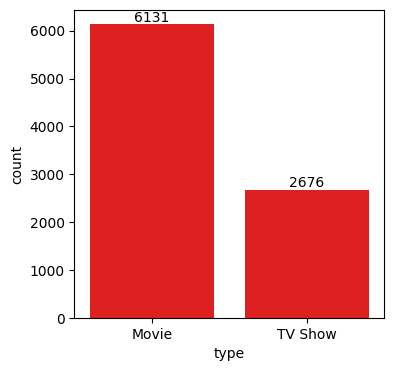

In [176]:
# Movies v/s TV Show

plt.figure(figsize = (4,4))
mov_tv = sns.countplot(data = netflix, x = 'type', color = 'r')

for container in mov_tv.containers:
    mov_tv.bar_label(container)

plt.show()

In [64]:
# Movies dominate the Netflix Collection with 6131 no. of movies and 2676 no. of TV Shows.

In [65]:
netflix.head(1)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,month_added,year_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",September,2021.0


In [66]:
netflix['year_added'].max(), netflix['year_added'].min()

(2021.0, 2008.0)

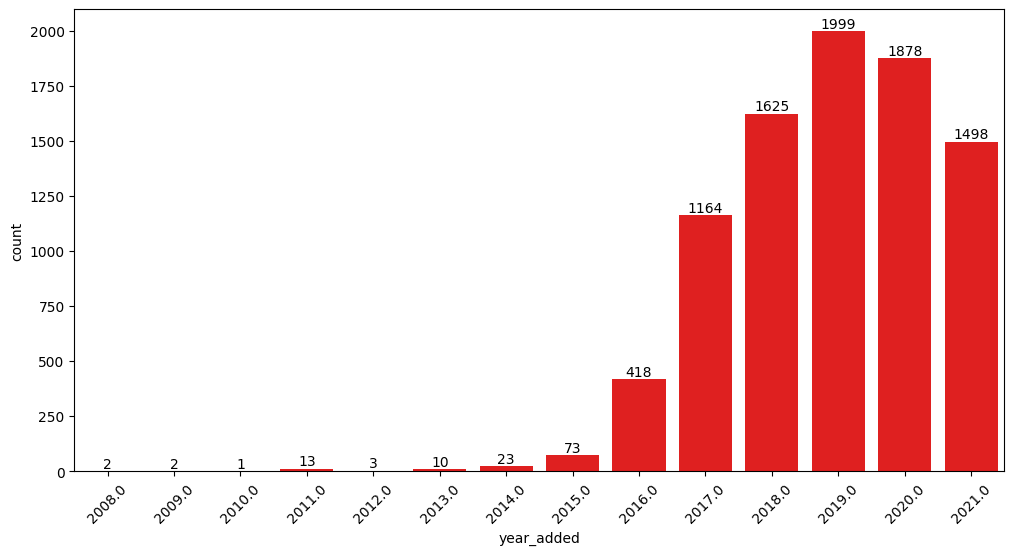

In [177]:
# Content made available every year

plt.figure(figsize = (12, 6))

fig = sns.countplot(data = netflix,  x = 'year_added', color = 'r')
for container in fig.containers:
    fig.bar_label(container)

plt.xticks(rotation = 45)
plt.show()

In [68]:
# In Year 2019, Netflix added most no. of contents, 2016 no. of titles, and least was in Year 2010.

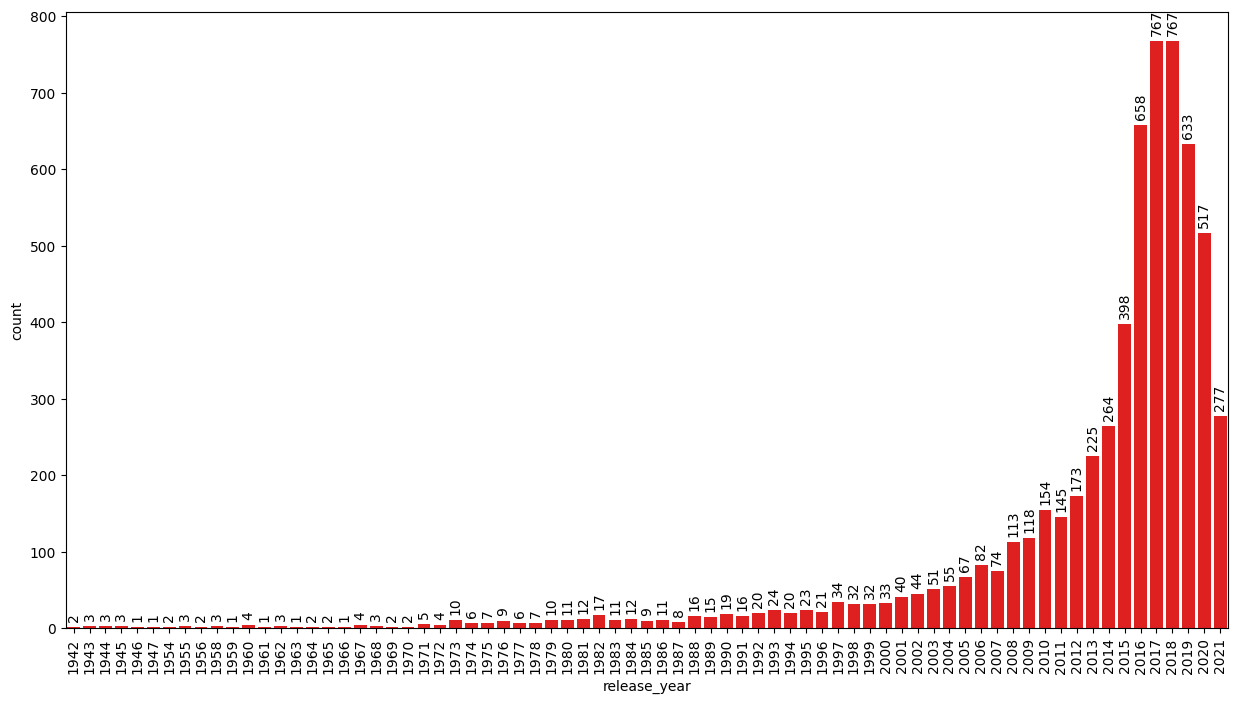

In [178]:
# Movies released every year

plt.figure(figsize = (15, 8))

ry = sns.countplot(data = netflix[netflix['type'] == 'Movie'],  x = 'release_year', color = 'red')
for container in ry.containers:
    ry.bar_label(container, rotation = 90, padding = 4)

plt.xticks(rotation = 90)
plt.show()

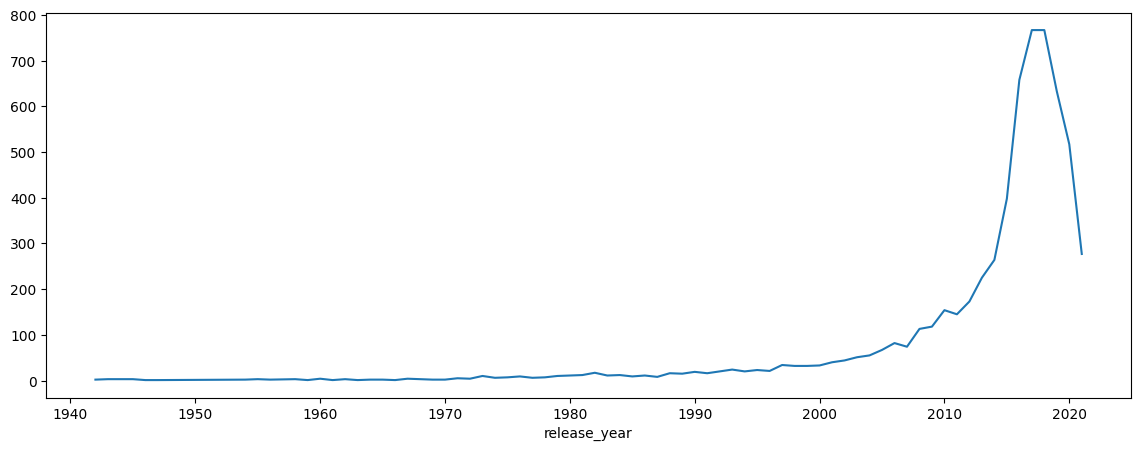

In [70]:
movie_df = netflix[netflix['type']=="Movie"]

movie_df['release_year'].value_counts().sort_index().plot(figsize=(14,5))
plt.show()

In [73]:
# Rating Distribution

netflix['rating'].nunique()

18

In [74]:
netflix['rating'].value_counts()

,count
rating,
TV-MA,3207
TV-14,2160
TV-PG,863
R,799
PG-13,490
TV-Y7,334
TV-Y,307
PG,287
TV-G,220


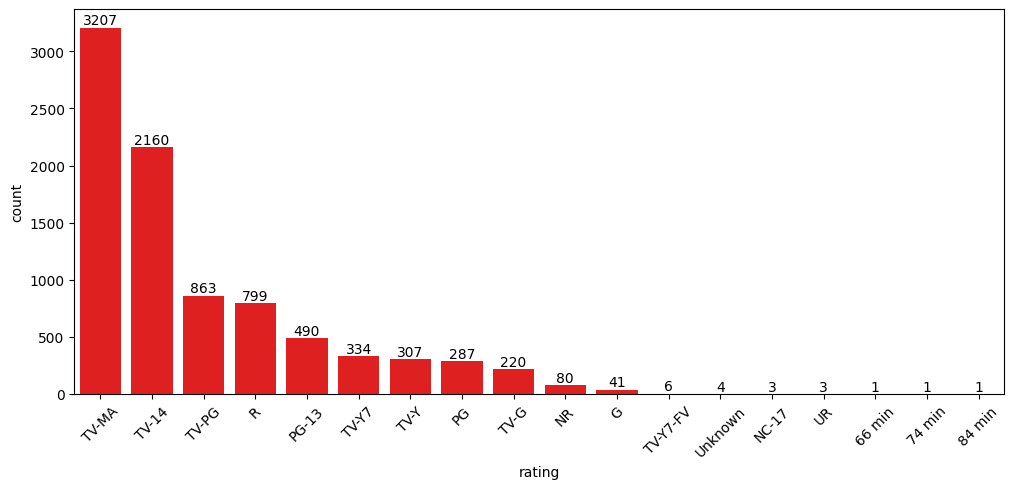

In [180]:
plt.figure(figsize = (12, 5))
rd = sns.countplot(data = netflix, x = 'rating', order = netflix['rating'].value_counts().index, color = 'r')
for container in rd.containers:
  rd.bar_label(container)

plt.xticks(rotation = 45)
plt.show()

In [ ]:
# Content Rated as TV-MA tops the charts for Ratings, means Netflix content attracts mostly adults above age 17,
# Ratings are then followed by TV-14 and TV-PG, i.e. contents attract teenagers and families where parental guidance is needed

Data Visualisation using the preprocessed columns

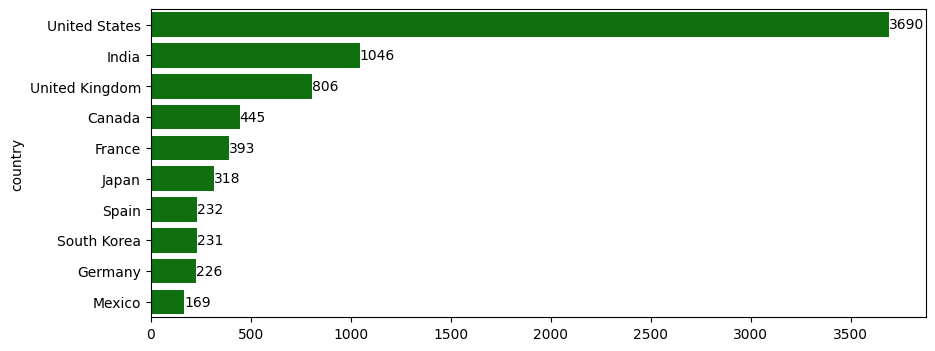

In [187]:
# Top Countries

plt.figure(figsize = (10, 4))

top_c = country_n[country_n['country'] != 'Unknown']['country'].value_counts().head(10)

tc = sns.barplot( x = top_c.values, y = top_c.index, color = 'green')
for container in tc.containers:
  tc.bar_label(container)

In [70]:
# The United States dominates Netflix's catalogue, indicating Netflix's strong dependence on Hollywood productions,
# while simultaneously expanding international content in countries such as India, Japan and South Korea,
# followed by India, United Kingdom, Canada, France
# Investments should be made in these Top countries to maintain and grow consumer attraction by providing more variety of content,
# For under performing Countries, promotions, auditions, advertisements campaogns can be run to attract directors, cast, consumer.

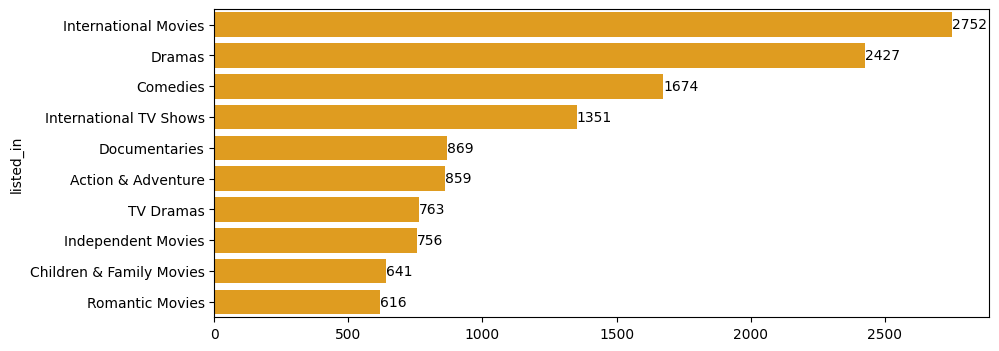

In [189]:
# Top Genres

plt.figure(figsize = (10, 4))

genres = listed_in_n['listed_in'].value_counts().head(10)

tg = sns.barplot(x = genres.values, y = genres.index, color = 'orange')
for container in tg.containers:
  tg.bar_label(container)

In [70]:
# Currently Netflix provides most no. of International Movies Genre content for its consumers, followed by Drama, Comedies, TV Shows,
# Documentaries, etc. TV Shows and TV Dramas are in Top 10 which reflects, they have popular among viewers in recent times.

In [70]:
# What is the best time to launch a TV show?
# Visualisation by Month added

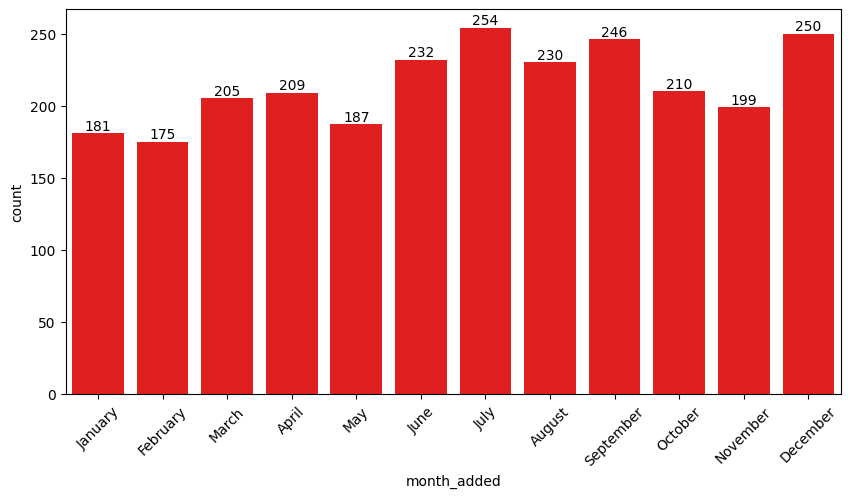

In [190]:
order = ["January","February","March","April","May","June","July","August","September","October","November","December"]

plt.figure(figsize = (10, 5))

ma = sns.countplot(data = netflix[netflix['type'] == 'TV Show'], x = 'month_added', order = order, color = 'r')
for container in ma.containers:
  ma.bar_label(container)

plt.xticks(rotation = 45)
plt.show()

In [132]:
# Netflix adds the TV Shows on to the platform when they are released, hence the best time to launch a TV Show is in month of July
# According to analysis, TV shows have been added the least in the month of February.
# The above charts shows TV Shows are being released most during the Year End winter Season, and least during start of New Year

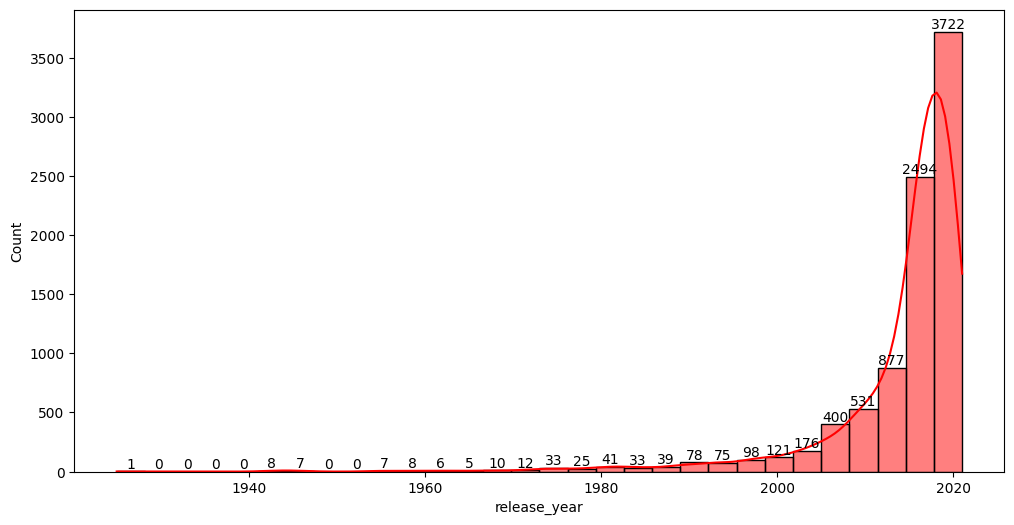

In [191]:
# Yearwise Release Distribution

plt.figure(figsize = (12, 6))

yr = sns.histplot(netflix['release_year'], bins = 30, kde = True, color = 'r')
for container in yr.containers:
  yr.bar_label(container)

plt.show()

In [70]:
# Netflix has mostly content available, which are released after 2000,
# and most no. of content being released during 2020-2021 with 3722 no. of titles being rleased.
# Netflix's library is heavily concentrated on titles released after 2000, indicating a strategic focus on contemporary content rather than classic cinema.

In [162]:
# Duration of Movies Analysis

movies = netflix[(netflix['type'] == 'Movie') & (netflix['duration'] != 'Unknown')].copy()
movies['duration_min'] = movies['duration'].str.replace(' min', '').astype(int)

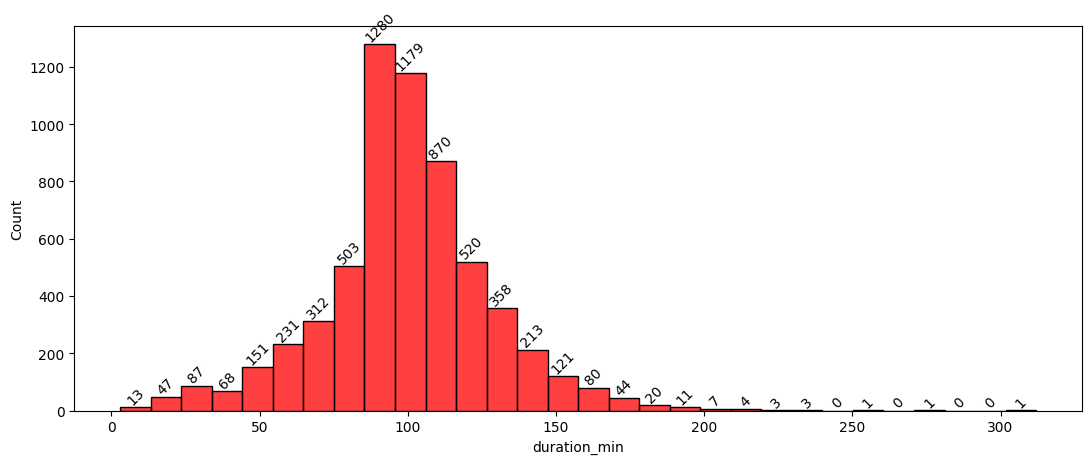

In [196]:
# histogram plot for varying durations

plt.figure(figsize = (13, 5))
mdh = sns.histplot(data = movies['duration_min'], bins = 30, color = 'r')
for container in mdh.containers:
  mdh.bar_label(container, rotation = 45)

In [206]:
# The Histogram plot shows that most of the movies available on Netflix have a duratrion in range 90 - 110 minutes, i,e around 1 hr 30 min.

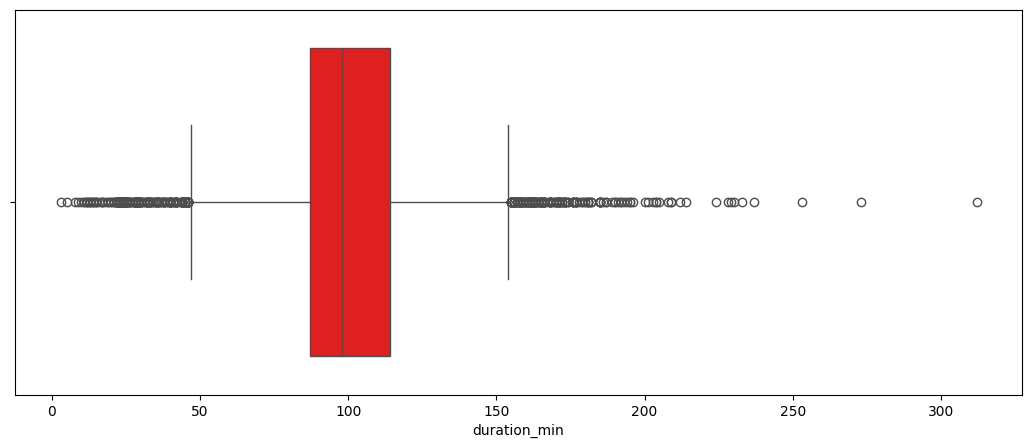

In [208]:
# Boxplot for duration statistics for Movies

plt.figure(figsize = (13, 5))
mdb = sns.boxplot(x= movies['duration_min'], color = 'r')

In [70]:
# The boxplot chart shows duration min has an average around 99 min.
# The analysis shows multiple movies as outliers in duration_min, which are unique and do not affect the chart data.
# The majority of movies have durations close to 100 minutes. A few movies exceed 200 minutes, appearing as outliers.
# This indicates that Netflix primarily focuses on standard feature-length movies while maintaining a small collection of exceptionally long films.

# Bivariate Analysis

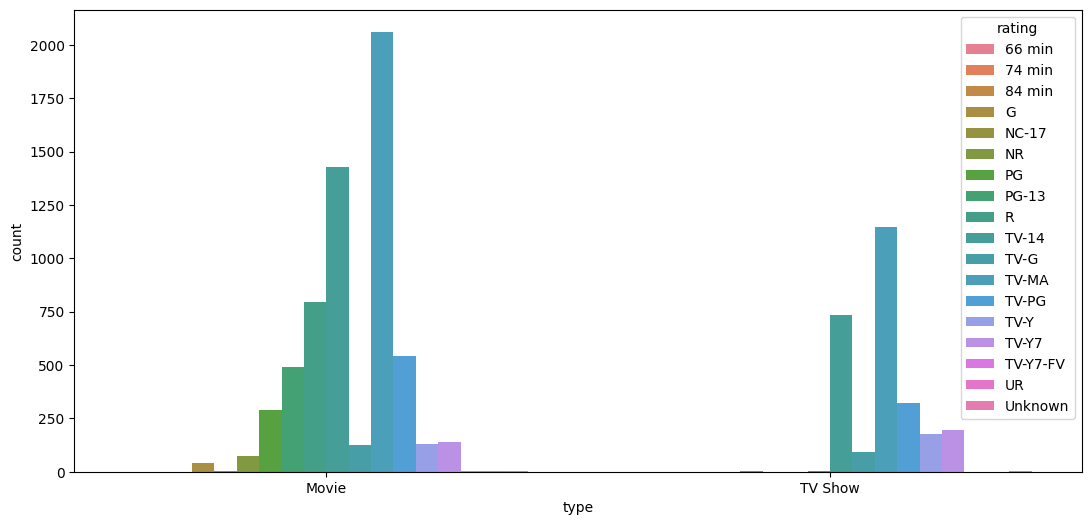

In [213]:
# Moviues and Rating relations

plt.figure(figsize = (13, 6))

mr = sns.countplot(data = netflix, x = 'type', hue = 'rating')

In [70]:
# In both type of contents, TV-MA ratinf tops the charts
# This indicates, Netflix attracting mostly matured viewers

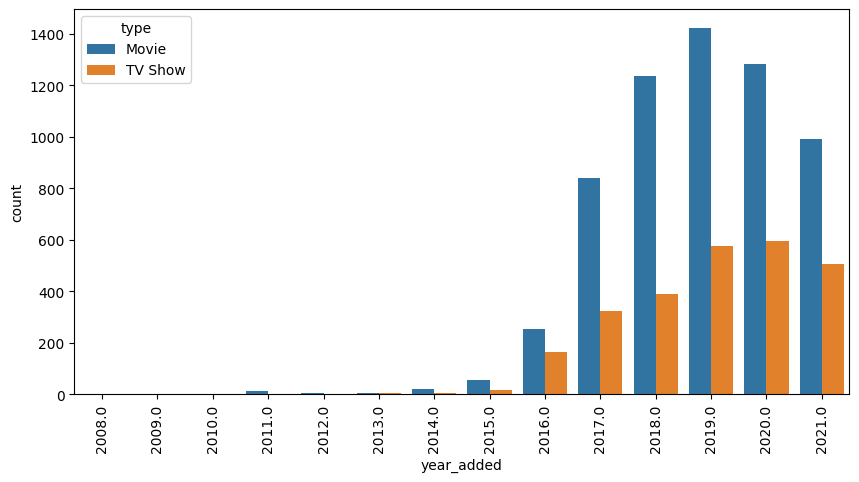

In [223]:
# Movies, TV Show and their Year Added
plt.figure(figsize = (10, 5))
mya = sns.countplot(data = netflix, x = 'year_added', hue = 'type'

plt.xticks(rotation = 90)
plt.show()

In [280]:
# The chart show, most no. of Movies were added in year 2019, where as most no. of TV Show were added in 2020

In [252]:
# Top Countries v/s Type

pd.crosstab(country_n['country'],country_n['type']).sort_values("Movie",ascending=False).head(10)

type,Movie,TV Show
country,,
United States,2752,938
India,962,84
United Kingdom,534,272
Unknown,440,391
Canada,319,126
France,303,90
Germany,182,44
Spain,171,61
Japan,119,199


In [253]:
# Top Actors and Types

pd.crosstab(cast_n['cast'],cast_n['type']).sort_values("Movie",ascending=False).head(10)

type,Movie,TV Show
cast,,
Unknown,475,350
Anupam Kher,42,1
Shah Rukh Khan,35,0
Naseeruddin Shah,32,0
Om Puri,30,0
Akshay Kumar,30,0
Amitabh Bachchan,28,0
Paresh Rawal,28,0
Julie Tejwani,28,5


In [282]:
# Top Directors and Types

pd.crosstab(director_n['director'],director_n['type']).sort_values("Movie",ascending=False).head(10)

type,Movie,TV Show
director,,
Unknown,188,2446
Rajiv Chilaka,22,0
Jan Suter,21,0
Raúl Campos,19,0
Suhas Kadav,16,0
Jay Karas,15,0
Marcus Raboy,15,1
Cathy Garcia-Molina,13,0
Martin Scorsese,12,0


# **Overall Business Insights**
1. Netflix has more Movies than TV Shows, which means movies are still the main type of content available on the platform.

2. The number of TV Shows has increased in recent years, showing that Netflix is focusing more on series to keep viewers engaged for a longer time.

3. The United States has the highest number of titles on Netflix, followed by countries like India, the United Kingdom, Canada, Japan, and South Korea. This shows that Netflix has a strong presence in these countries.

4. Most of the content available on Netflix was released after the year 2000, which means Netflix mainly offers recent and modern content.

5. Genres like Drama, International Movies, Comedy, and Documentaries are the most common on Netflix. This shows that viewers enjoy these types of content the most.

6. Most movies have a duration of 80 to 120 minutes, which is the standard length for feature films.

7. TV-MA is the most common content rating, which means Netflix mainly targets adult audiences.

8. Netflix works with many different directors and actors instead of depending on only a few people. This helps keep the content library diverse.

9. The number of titles added to Netflix increased rapidly until around 2019, showing that Netflix expanded its content library quickly during that period.

10. Overall, Netflix has a large and diverse content library with content from many countries, genres, and creators, helping it attract viewers from around the world.

# **Recommendations**
1. Netflix should continue investing in TV Shows because they keep viewers engaged for a longer time.

2. Netflix should produce more local content in countries like India, Japan, and South Korea, where regional content is becoming more popular.

3. Netflix should continue making more content in popular genres like Drama, Comedy, and International Movies since these genres have a large audience.

4. Netflix can build long-term partnerships with directors and actors who have contributed several successful titles.

5. Netflix should increase the amount of family and children's content to attract more viewers of all age groups.

6. The company should maintain a good balance between Movies and TV Shows so that different types of viewers can find content they enjoy.

7. Netflix should use data from different countries to understand local audience preferences before producing new content.

8. Netflix should continue expanding its content library with high-quality original content to attract new subscribers and retain existing ones.

# **Comclusion**

- From this analysis, we can conclude that Netflix has a diverse collection of movies and TV shows from different countries and genres. The platform is gradually increasing its focus on TV Shows while continuing to offer a large number of movies. By producing more local content, investing in popular genres, and using audience preferences to guide future decisions, Netflix can continue to grow its business and improve customer satisfaction.






